# Raster scan from Fort Sumner, NM

Generates an input sky (CMB + foregrounds) and simulates a raster
scanning strategy from Fort Sumner, New Mexico -- the NASA long-duration
balloon launch site -- then bins the observed TOD back into a map to
check consistency against the input.


In [1]:
%matplotlib inline
import litebird_sim as lbs
import numpy as np
from swipe_modules import SwipeRasterScanningStrategy
import matplotlib.pyplot as plt
import healpy as hp
import astropy
from astropy import units as u
from astropy.coordinates import SkyCoord, AltAz, EarthLocation, get_sun, get_body

## Site and scan settings

Fort Sumner, NM: latitude 34.49 deg N, longitude -104.2218 deg E.


In [2]:
site_latitude_deg = 34.4900
site_longitude_deg = -104.2218

elevation_deg = 50.0
azimuth_start_deg = 120.0
azimuth_amplitude_deg = 40.0
azimuth_scan_speed_deg_per_s = 1.0

duration_h = 2.0
sampling_rate_hz = 20
nside = 128

In [3]:
sim = lbs.Simulation(
    start_time=astropy.time.Time("2026-09-30T19:30", scale="utc"),
    duration_s=duration_h * 3600,
    description="SWIPE raster scan from Fort Sumner, NM",
    random_seed=123456,
)

scanning = SwipeRasterScanningStrategy(
    site_latitude_deg=site_latitude_deg,
    site_longitude_deg=site_longitude_deg,
    azimuth_start_deg=azimuth_start_deg,
    azimuth_amplitude_deg=azimuth_amplitude_deg,
    azimuth_scan_speed_deg_per_s=azimuth_scan_speed_deg_per_s,
)

instr = lbs.InstrumentInfo(
    name="swipe",
    spin_boresight_angle_rad=np.deg2rad(90.0 - elevation_deg),
)

# delta_time_s must be small compared to the azimuth turnaround time
# (amplitude / speed = 40 s here), otherwise the raster pattern is
# undersampled between quaternions.
sim.set_scanning_strategy(scanning, delta_time_s=0.1)
sim.set_instrument(instr)

[2026-08-27 11:50:10,432 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


[2026-08-27 11:50:10,433 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


site_latitude_deg, site_longitude_deg and longitude_speed_deg_per_sec used


## Detectors

A boresight pair at 0/45 deg polarization angle.

In [4]:
det0 = lbs.DetectorInfo(
    name="Boresight_detector_0",
    sampling_rate_hz=sampling_rate_hz,
    bandcenter_ghz=145.0,
    quat=[0.0, 0.0, 0.0, 1.0],
    fwhm_arcmin=60.0,
    net_ukrts=12.6999998,
)

det1 = lbs.DetectorInfo(
    name="Boresight_detector_1",
    sampling_rate_hz=sampling_rate_hz,
    bandcenter_ghz=145.0,
    quat=[0.0, 0.0, 1.0 / np.sqrt(2.0), 1.0 / np.sqrt(2.0)],
    fwhm_arcmin=60.0,
    net_ukrts=12.6999998,
)

In [5]:
obs, = sim.create_observations(detectors=[det0, det1])
sim.prepare_pointings()
sim.precompute_pointings()

## Sky coverage

Hit map of the raster scan on the sky (Ecliptic coordinates), before
any sky signal is injected.


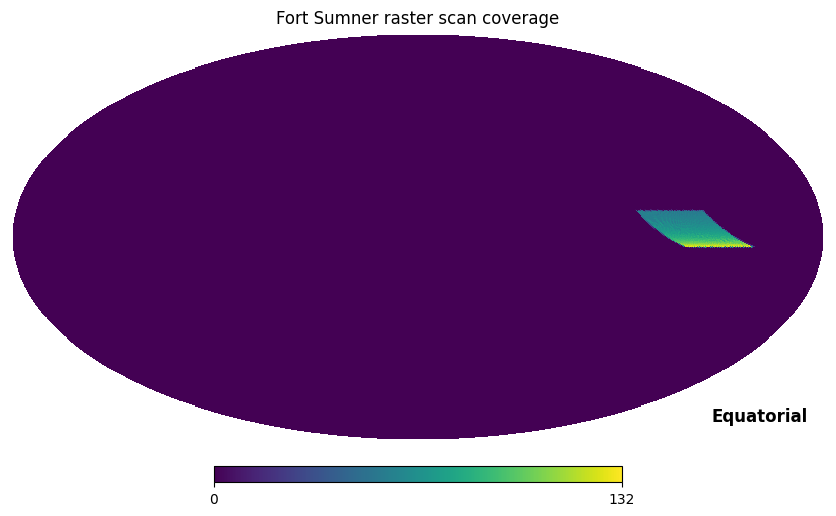

In [6]:
npix = hp.nside2npix(nside)
h = np.zeros(npix)
for idet in [0]:
    pixidx = hp.ang2pix(nside, obs.pointing_matrix[idet, :, 0], obs.pointing_matrix[idet, :, 1])
    pixel_occurrences = np.bincount(pixidx)
    h[0:len(pixel_occurrences)] += pixel_occurrences

hp.mollview(h, coord=["E", "C"], title="Fort Sumner raster scan coverage")

## Sky context: Sun, Moon, planets, Galactic plane

Overlay the Sun, Moon, the outer planets, the Galactic plane, and the
Crab Nebula on the scan coverage, both in equatorial and Galactic
coordinates. Adapted from ``tools/swipe_rasterscan_turnaround.ipynb``.


In [7]:
times = sim.start_time + np.linspace(0, sim.duration_s, 200) * u.second

site = EarthLocation(lat=site_latitude_deg * u.deg, lon=site_longitude_deg * u.deg, height=0 * u.km)
altaz_frame = AltAz(obstime=times, location=site)

sun_equatorial = get_sun(times)
moon_equatorial = get_body("moon", times)
mars_equatorial = get_body("mars", times)
jupiter_equatorial = get_body("jupiter", times)
saturn_equatorial = get_body("saturn", times)

galplane_galactic = SkyCoord(l=np.arange(0, 360) * u.degree, b=0 * u.degree, frame="galactic")
galplane_equatorial = galplane_galactic.transform_to("icrs")

# Crab Nebula (M1), hardcoded rather than resolved by name to avoid a
# network lookup: RA=05h34m31.94s, Dec=+22d00m52.2s (J2000).
crab_equatorial = SkyCoord(ra="5h34m31.94s", dec="22d00m52.2s", frame="icrs")

[2026-08-27 11:50:13,018 INFO MPI#0000] 0.0 180.0 -180.0 180.0


[2026-08-27 11:50:13,019 INFO MPI#0000] The interval between parallels is 30 deg -0.00'.


[2026-08-27 11:50:13,019 INFO MPI#0000] The interval between meridians is 30 deg -0.00'.


[2026-08-27 11:50:13,600 INFO MPI#0000] 0.0 180.0 -180.0 180.0


[2026-08-27 11:50:13,600 INFO MPI#0000] The interval between parallels is 30 deg -0.00'.


[2026-08-27 11:50:13,601 INFO MPI#0000] The interval between meridians is 30 deg -0.00'.


[2026-08-27 11:50:13,608 INFO MPI#0000] 0.0 180.0 -180.0 180.0


[2026-08-27 11:50:13,609 INFO MPI#0000] The interval between parallels is 30 deg -0.00'.


[2026-08-27 11:50:13,609 INFO MPI#0000] The interval between meridians is 30 deg -0.00'.


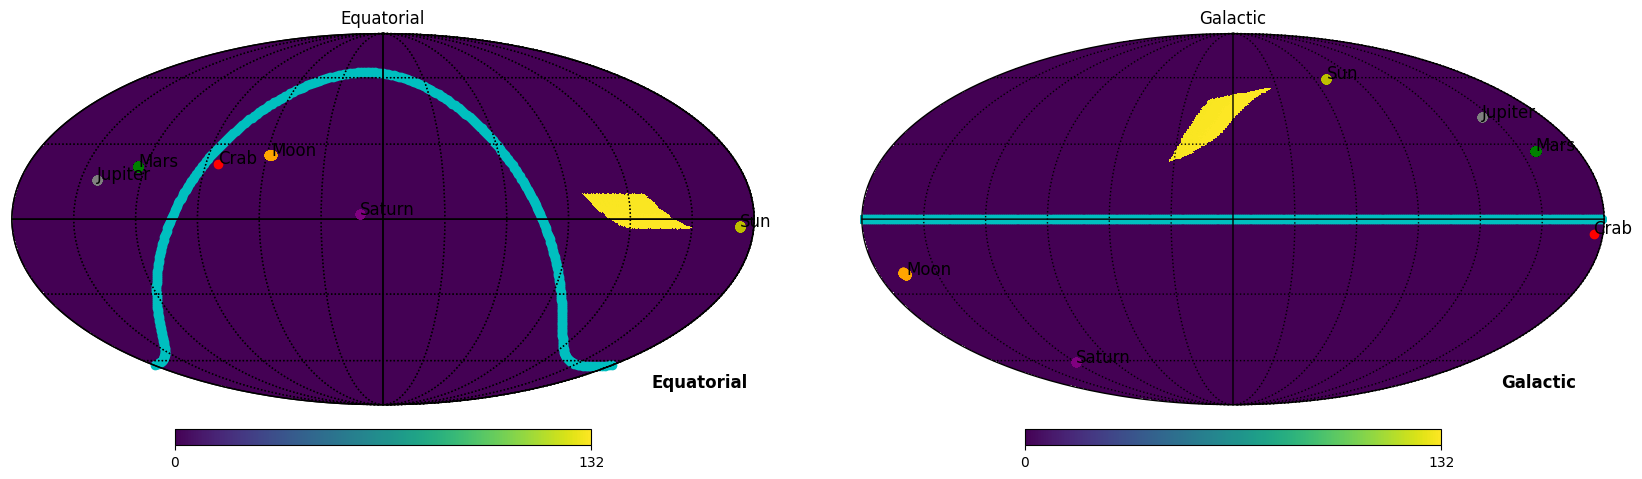

In [8]:
def _overlay(coord):
    for body, name, color in [
        (sun_equatorial, "Sun", "y"),
        (moon_equatorial, "Moon", "orange"),
        (mars_equatorial, "Mars", "g"),
        (jupiter_equatorial, "Jupiter", "grey"),
        (saturn_equatorial, "Saturn", "purple"),
    ]:
        hp.projscatter(body.ra, body.dec, lonlat=True, color=color, coord=["C", coord], zorder=99)
        hp.projtext(body.ra[0], body.dec[0], name, lonlat=True, fontsize=12, coord=["C", coord], zorder=99)

    hp.projscatter(
        crab_equatorial.ra, crab_equatorial.dec, lonlat=True, color="r", coord=["C", coord], zorder=99
    )
    hp.projtext(
        crab_equatorial.ra, crab_equatorial.dec, "Crab", lonlat=True, fontsize=12, coord=["C", coord], zorder=99
    )

    hp.projscatter(galplane_equatorial.ra, galplane_equatorial.dec, lonlat=True, color="c", coord=["C", coord])
    hp.graticule()


plt.figure(figsize=(17, 4.5))
hp.mollview(h, sub=121, coord=["E", "C"], norm="hist", title="Equatorial")
_overlay("C")
hp.mollview(h, sub=122, coord=["E", "G"], norm="hist", title="Galactic")
_overlay("G")

## Input sky

Generate a CMB + foreground sky (``input_sky``-style generation via
``SkyGenerationParams``), observe it with the raster-scan pointing,
inject white noise, and bin the resulting TOD back into a map.


In [9]:
sky_params = lbs.SkyGenerationParams(
    make_cmb=True,
    make_fg=True,
    fg_models=["s0", "f1", "d0"],  # set the FG models you want
    seed_cmb=1,  # set this seed if you want to fix the CMB realization
    apply_beam=True,  # if True, smooths the input map by the beam of the channel
    bandpass_integration=False,  # if True, integrates over the top-hat bandpass of the channel
    units="K_CMB",
    output_type="map",
    nside=nside,
)

in_map = sim.get_sky(parameters=sky_params, channels=[det0, det1], store_in_observation=True)

[2026-08-27 11:50:13,772 INFO MPI#0000] Generating CMB...


[2026-08-27 11:50:13,834 INFO MPI#0000] Generating Foregrounds...


[2026-08-27 11:50:13,835 INFO MPI#0000] Retrieve data for pysm_2/synch_t_new.fits (if not cached already)


[2026-08-27 11:50:13,837 INFO MPI#0000] NSIDE = 512


[2026-08-27 11:50:13,837 INFO MPI#0000] ORDERING = RING in fits file


...

[2026-08-27 11:50:14,218 INFO MPI#0000] Retrieve data for pysm_2/dust_u_new.fits (if not cached already)


[2026-08-27 11:50:14,220 INFO MPI#0000] NSIDE = 512


[2026-08-27 11:50:14,220 INFO MPI#0000] ORDERING = RING in fits file


[2026-08-27 11:50:14,221 INFO MPI#0000] INDXSCHM = IMPLICIT


[2026-08-27 11:50:15,819 INFO MPI#0000] Summing components...


In [10]:
sim.fill_tods(in_map)
sim.add_noise(noise_type="white")

In [11]:
results = sim.make_binned_map(nside)

## Binned map vs. input sky

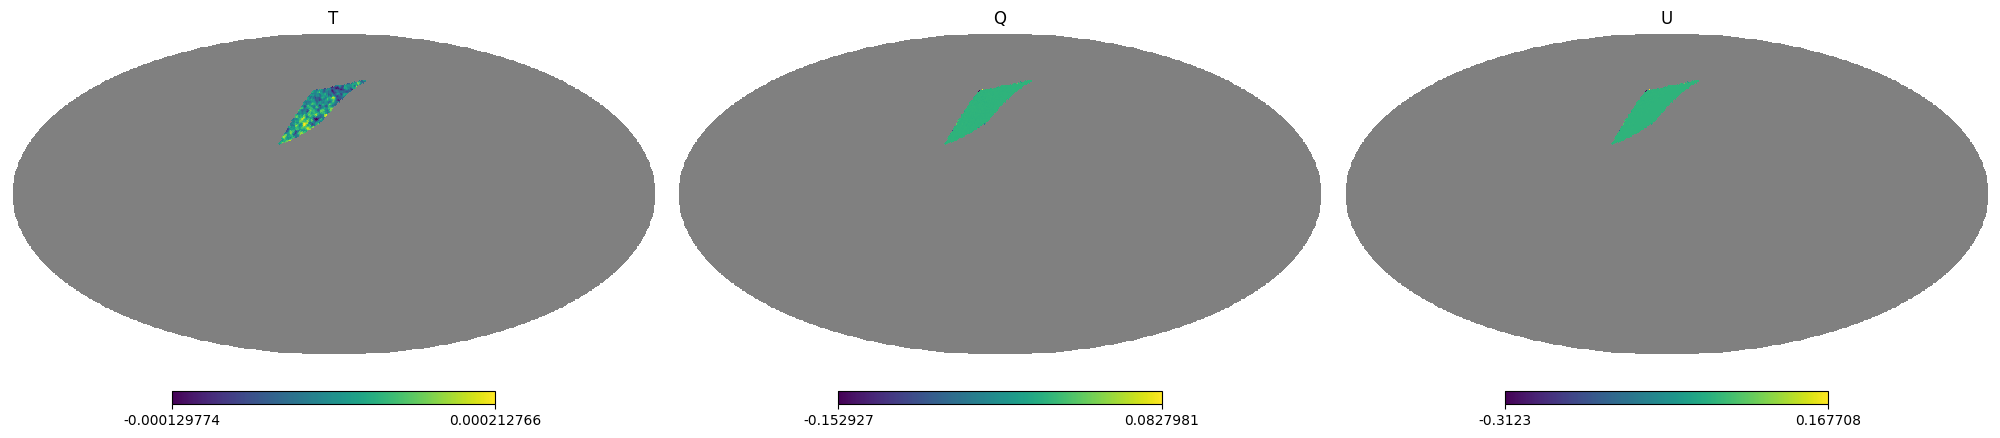

In [12]:
plt.figure(figsize=(20, 7))
hp.mollview(results.binned_map[0], sub=131, title="T")
hp.mollview(results.binned_map[1], sub=132, title="Q")
hp.mollview(results.binned_map[2], sub=133, title="U")

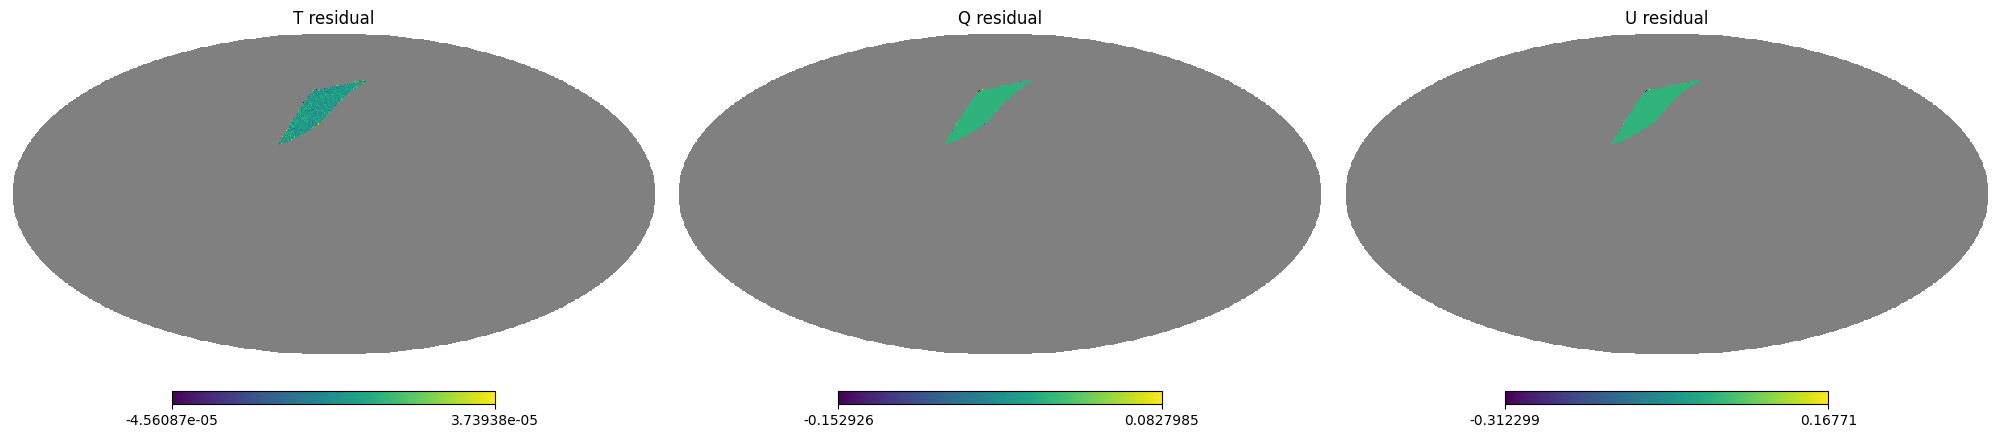

In [13]:
plt.figure(figsize=(20, 7))
hp.mollview(results.binned_map[0] - in_map["Boresight_detector_0"].values[0], sub=131, title="T residual")
hp.mollview(results.binned_map[1] - in_map["Boresight_detector_0"].values[1], sub=132, title="Q residual")
hp.mollview(results.binned_map[2] - in_map["Boresight_detector_0"].values[2], sub=133, title="U residual")